# The density of states: smearing and tetrahedra

How many states per unit energy the crystal has — a Brillouin-zone integral of a delta
function, which is the one integral a finite k-grid is bad at. Two families answer it:
**smearing**, which replaces the delta by something of finite width, and **tetrahedra**,
which interpolate the bands linearly and integrate exactly. Both are here, both also work
as occupation schemes inside the SCF, and QE's three aluminium benchmarks come out to
**2.5e-8 Ry** with the Fermi levels agreeing to a fraction of a meV.

What is wanted is a Brillouin-zone integral of a delta function, and what a smearing
scheme actually writes down is its *integral* -- the count of states below $E$ -- with
the density of states as the derivative:

$$D(E) = \sum_n \int_{\rm BZ} \frac{d\mathbf k}{(2\pi)^3}\,
        \delta(E - \varepsilon_{n\mathbf k})
\qquad\Longleftarrow\qquad
N(E) = \sum_{n\mathbf k} w_{\mathbf k}\,
       f\!\left(\frac{E - \varepsilon_{n\mathbf k}}{\sigma}\right),
\quad D = \frac{dN}{dE}$$

Phases P8 and P9.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.scf.occupations import w0gauss, wgauss
from pypresso.units import RY_TO_EV
from pypresso.workflows import denser_grid, run_nscf

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
PSEUDO = Path("../tests/data/pseudo")


def load(path):
    return Calculator.from_file(path, pseudo_dir=PSEUDO, announce=False)


# A DOS is a *non-self-consistent* run: converge the density on the coarse SCF grid, then
# diagonalise once on a much denser one at fixed potential. Nothing is self-consistent
# about that second step, which is why it can afford ten times the k-points.
si = load(QE / "pw_scf" / "scf.in")
si_scf = si.get_scf(conv_thr=1e-10)
nscf = si.get_nscf(kpoints=denser_grid(si.system, (12, 12, 12)), nbnd=8)

valence_top = nscf.eigenvalues[:, 3].max()
conduction_bottom = nscf.eigenvalues[:, 4].min()
print("SCF: %d k-points, E = %.8f Ry"
      % (si.system.kpoints.nk, si_scf.total_energy))
print("DOS: 12x12x12 -> %d irreducible k-points, %d bands"
      % (nscf.kpoints.nk, nscf.eigenvalues.shape[1]))
print("indirect gap %.4f eV" % ((conduction_bottom - valence_top) * RY_TO_EV))

SCF: 2 k-points, E = -15.79449557 Ry
DOS: 12x12x12 -> 72 irreducible k-points, 8 bands
indirect gap 0.4790 eV


## The smeared delta is the derivative of the occupation function

Only $N(E)$, the number of states below $E$, is written down here — as a sum of occupation
functions — and $D(E)$ is `jax.grad` of it. That is not a trick: `w0gauss` *is*
`d(wgauss)/dx` in QE too, hand-differentiated, and the four smearing families differ only
in which occupation function they use. Each one integrates to exactly 1, however shaped.

Gaussian                   integral = 1.0000000000
Methfessel-Paxton          integral = 1.0000000000
cold (Marzari-Vanderbilt)  integral = 1.0000000000


Fermi-Dirac                integral = 1.0000000000


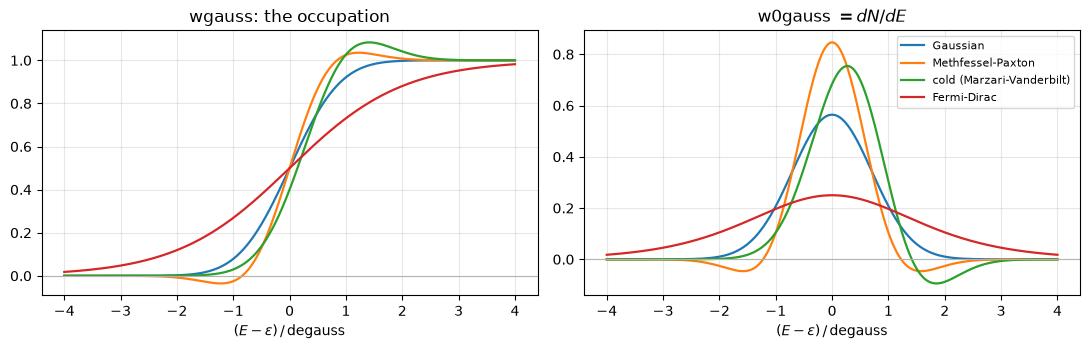

In [2]:
x = np.linspace(-4, 4, 801)
names = {0: "Gaussian", 1: "Methfessel-Paxton", -1: "cold (Marzari-Vanderbilt)",
         -99: "Fermi-Dirac"}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ngauss, label in names.items():
    axes[0].plot(x, wgauss(x, ngauss), lw=1.6, label=label)
    axes[1].plot(x, w0gauss(x, ngauss), lw=1.6, label=label)
axes[0].set_title("wgauss: the occupation"); axes[1].set_title(r"w0gauss $= dN/dE$")
for ax in axes:
    ax.set_xlabel(r"$(E - \varepsilon)\,/\,$degauss"); ax.axhline(0, color="0.7", lw=0.8)
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8); fig.tight_layout()

wide = np.linspace(-40, 40, 400001)
for ngauss, label in names.items():
    print("%-26s integral = %.10f"
          % (label, np.trapezoid(np.asarray(w0gauss(wide, ngauss)), wide)))

## Silicon: the gap is what separates the two schemes

Inside a gap the true DOS is exactly zero. Tetrahedra reproduce that; a Gaussian of width
0.02 Ry smears occupied states into it and leaves a floor five orders of magnitude
higher. For a metal the ordering is reversed — smearing is what makes the Fermi surface
integrable — which is why both families exist and neither is a default for everything.

D at mid-gap: tetrahedra 0.00e+00, Gaussian 2.73e-02 states/eV
N above the highest band = 15.9999999995   (8 bands x 2)


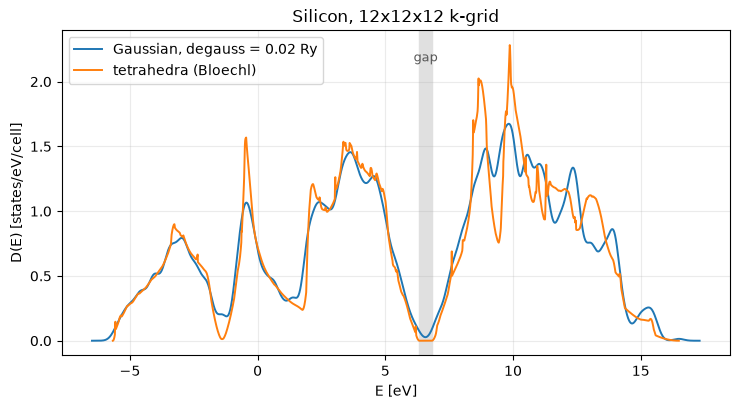

In [3]:
dos_tetra = si.get_dos(grid=(12, 12, 12), nbnd=8, scheme="tetrahedra")
dos_gauss = si.get_dos(grid=(12, 12, 12), nbnd=8, scheme="gaussian", degauss=0.02)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(dos_gauss.energies_ev, dos_gauss.dos_ev, lw=1.4,
        label="Gaussian, degauss = 0.02 Ry")
ax.plot(dos_tetra.energies_ev, dos_tetra.dos_ev, lw=1.4, label="tetrahedra (Bloechl)")
ax.axvspan(valence_top * RY_TO_EV, conduction_bottom * RY_TO_EV, color="0.88", zorder=0)
ax.text(0.5 * (valence_top + conduction_bottom) * RY_TO_EV, 0.9 * ax.get_ylim()[1],
        "gap", ha="center", fontsize=9, color="0.35")
ax.set_xlabel("E [eV]"); ax.set_ylabel("D(E) [states/eV/cell]")
ax.set_title("Silicon, 12x12x12 k-grid"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()

middle = 0.5 * (valence_top + conduction_bottom)
print("D at mid-gap: tetrahedra %.2e, Gaussian %.2e states/eV"
      % (dos_tetra.at(middle) / RY_TO_EV, dos_gauss.at(middle) / RY_TO_EV))
print("N above the highest band = %.10f   (8 bands x 2)" % dos_tetra.integrated[-1])

## Aluminium, against Quantum ESPRESSO

A metal is where the scheme decides the answer rather than the picture: the occupations
themselves depend on it, so the total energy does. QE's `pw_metal` benchmarks cover all
three tetrahedron variants — linear, Bloechl-corrected, and the optimised one — and the
SCF here uses the same scheme it reports.

In [4]:
al = load(QE / "pw_metal" / "metal-tetrahedra.in")
al_scf = al.get_scf(conv_thr=1e-10)
al_ref = read_qe_output(QE / "pw_metal" / "benchmark.out.git.inp=metal-tetrahedra.in")

print("occupations = %r, %d irreducible k-points"
      % (al.system.occupations, al.system.kpoints.nk))
print("%-24s%16s%20s%14s" % ("", "pypresso", "Quantum ESPRESSO", "difference"))
print("%-24s%16.8f%20.8f%14.2e"
      % ("total energy (Ry)", al_scf.total_energy, al_ref.total_energy,
         al_scf.total_energy - al_ref.total_energy))
print("%-24s%16.4f%20.4f%14.2e"
      % ("Fermi energy (eV)", al_scf.fermi_energy * RY_TO_EV, al_ref.fermi_energy,
         al_scf.fermi_energy * RY_TO_EV - al_ref.fermi_energy))

print("\n%-26s%18s%14s%12s" % ("the other two variants", "occupations",
                               "E_F pypresso", "QE E_F"))
for name in ("metal-tetrahedra-1.in", "metal-tetrahedra-2.in"):
    # A *different* system -- another tetrahedron variant -- read at the density
    # `al` converged. One calculator cannot say that, so this is the functional
    # call, which is what it is still for.
    system = load(QE / "pw_metal" / name).system
    result = run_nscf(system, al.pseudos, al_scf.density, nbnd=4)
    theirs = read_qe_output(QE / "pw_metal" / f"benchmark.out.git.inp={name}")
    print("%-26s%18s%14.4f%12.4f"
          % (name, system.occupations, result.fermi_energy * RY_TO_EV,
             theirs.fermi_energy))

occupations = 'tetrahedra-opt', 10 irreducible k-points
                                pypresso    Quantum ESPRESSO    difference
total energy (Ry)            -4.16607791         -4.16607788     -2.55e-08
Fermi energy (eV)                 8.1535              8.1533      2.36e-04

the other two variants           occupations  E_F pypresso      QE E_F


metal-tetrahedra-1.in             tetrahedra        8.3056      8.3056


metal-tetrahedra-2.in         tetrahedra-lin        8.2622      8.2622


states below E_F = 3.000003   (3 valence electrons)
D(E_F)           = 0.3751 states/eV/cell


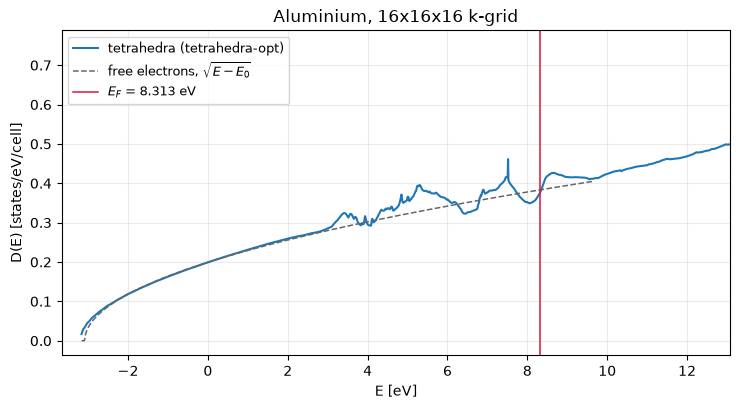

In [5]:
al_dos = al.get_dos(grid=(16, 16, 16), nbnd=6)
# The states it integrated are left on the calculator; the DOS itself is returned.
ef, bottom = al_dos.fermi_energy, al.dos_states.eigenvalues.min()

window = (al_dos.energies > bottom + 0.03) & (al_dos.energies < bottom + 0.30)
slope, intercept = np.polyfit(al_dos.energies[window], al_dos.dos[window] ** 2, 1)
sqrt_law = np.sqrt(np.maximum(slope * al_dos.energies + intercept, 0.0))
shown = al_dos.energies < ef + 0.1

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(al_dos.energies_ev, al_dos.dos_ev, lw=1.5, label="tetrahedra (%s)" % al_dos.scheme)
ax.plot(al_dos.energies_ev[shown], (sqrt_law / RY_TO_EV)[shown], "--", lw=1.1, color="0.4",
        label=r"free electrons, $\sqrt{E - E_0}$")
ax.axvline(ef * RY_TO_EV, color="crimson", lw=1.1,
           label=r"$E_F$ = %.3f eV" % (ef * RY_TO_EV))
ax.set_xlim(bottom * RY_TO_EV - 0.5, (ef + 0.35) * RY_TO_EV)
ax.set_xlabel("E [eV]"); ax.set_ylabel("D(E) [states/eV/cell]")
ax.set_title("Aluminium, 16x16x16 k-grid"); ax.legend(fontsize=9); ax.grid(alpha=0.25)
fig.tight_layout()

print("states below E_F = %.6f   (3 valence electrons)" % al_dos.states_below(ef))
print("D(E_F)           = %.4f states/eV/cell" % (al_dos.at(ef) / RY_TO_EV))

Aluminium is the textbook free-electron metal and the calculation says so: $\sqrt{E}$
almost all the way to $E_F$, and the integrated states come back as three electrons.

The spin-resolved version of this plot — nickel's two channels and the moment read off
the integrated curves — is in notebook 07.

---
**The detail:** `PLAN.md` §3 P8 — the three tetrahedron variants, the occupation schemes
inside the SCF, and the NaN that appears only in the gradient (a degenerate tetrahedron
whose zero-weighted branch is still differentiated, which is why every denominator is
clamped before the division rather than after).
**The tests:** `tests/regression/test_dos.py`, `tests/regression/test_tetrahedra.py`,
`tests/unit/test_bz_integration.py`.